In [ ]:
!pip install stim
import stim
class surface_code:
    def __init__(self, distance):
        self.distance = distance
        self.circuit = self.build_circuit()
        self.n_data_qubits = self.distance**2
        self.data_qubits = list(range(self.n_data_qubits))
        self.x_ancillas = list(range(self.n_data_qubits, 
                                     self.n_data_qubits+ self.n_data_qubits))
        self.z_ancillas = list(range(self.n_data_qubits+ self.n_data_qubits, 
                                     self.n_data_qubits+ self.n_data_qubits))
        self.circuit = stim.Circuit()
        self.circuit.append("R", data + x_anc + z_anc)
        self.x_parity_check_matrix
        self.y_parity_check_matrix 

    def x_stabiliser(self):
        self.circuit.append("H", x_anc) # Prepare X ancillas in |+>
        x_stabilizers = [(9,  [0, 1, 3, 4]), # (ancilla, data qubits it touches)
                        (10, [1, 2, 4, 5]),
                        (11, [3, 4, 6, 7]),
                        (12, [4, 5, 7, 8]),]

        for anc, targets in x_stabilizers:
            for d in targets:
                circuit.append("CX", [anc, d]) # CNOT pattern for rotated d=3 surface code 

        circuit.append("H", x_anc) # Return ancillas to Z basis

        circuit.append("M", x_anc) # Measure X ancillas
        return circuit
    
circuit = stim.Circuit() # Create circuit

data = list(range(9)) # Data qubits: 0–8
x_anc = list(range(9, 13)) # X ancillas: 9–12
z_anc = list(range(13, 17)) # Z ancillas: 13–16

circuit.append("R", data + x_anc + z_anc) # Reset all qubits 

circuit.append("H", x_anc) # Prepare X ancillas in |+>

x_stabilizers = [(9,  [0, 1, 3, 4]), # (ancilla, data qubits it touches)
                 (10, [1, 2, 4, 5]),
                 (11, [3, 4, 6, 7]),
                 (12, [4, 5, 7, 8]),]

for anc, targets in x_stabilizers:
    for d in targets:
        circuit.append("CX", [anc, d]) # CNOT pattern for rotated d=3 surface code 

circuit.append("H", x_anc) # Return ancillas to Z basis

circuit.append("M", x_anc) # Measure X ancillas

# Z stabilizer measurements
z_stabilizers = [(13, [0, 1, 3, 4]),
                 (14, [1, 2, 4, 5]),
                 (15, [3, 4, 6, 7]),
                 (16, [4, 5, 7, 8]),]

for anc, targets in z_stabilizers:
    for d in targets:
        circuit.append("CX", [d, anc])  # reversed order for Z stabilizers

# Measure Z ancillas
circuit.append("M", z_anc)

print(circuit)


R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
H 9 10 11 12
CX 9 0 9 1 9 3 9 4 10 1 10 2 10 4 10 5 11 3 11 4 11 6 11 7 12 4 12 5 12 7 12 8
H 9 10 11 12
M 9 10 11 12
CX 0 13 1 13 3 13 4 13 1 14 2 14 4 14 5 14 3 15 4 15 6 15 7 15 4 16 5 16 7 16 8 16
M 13 14 15 16


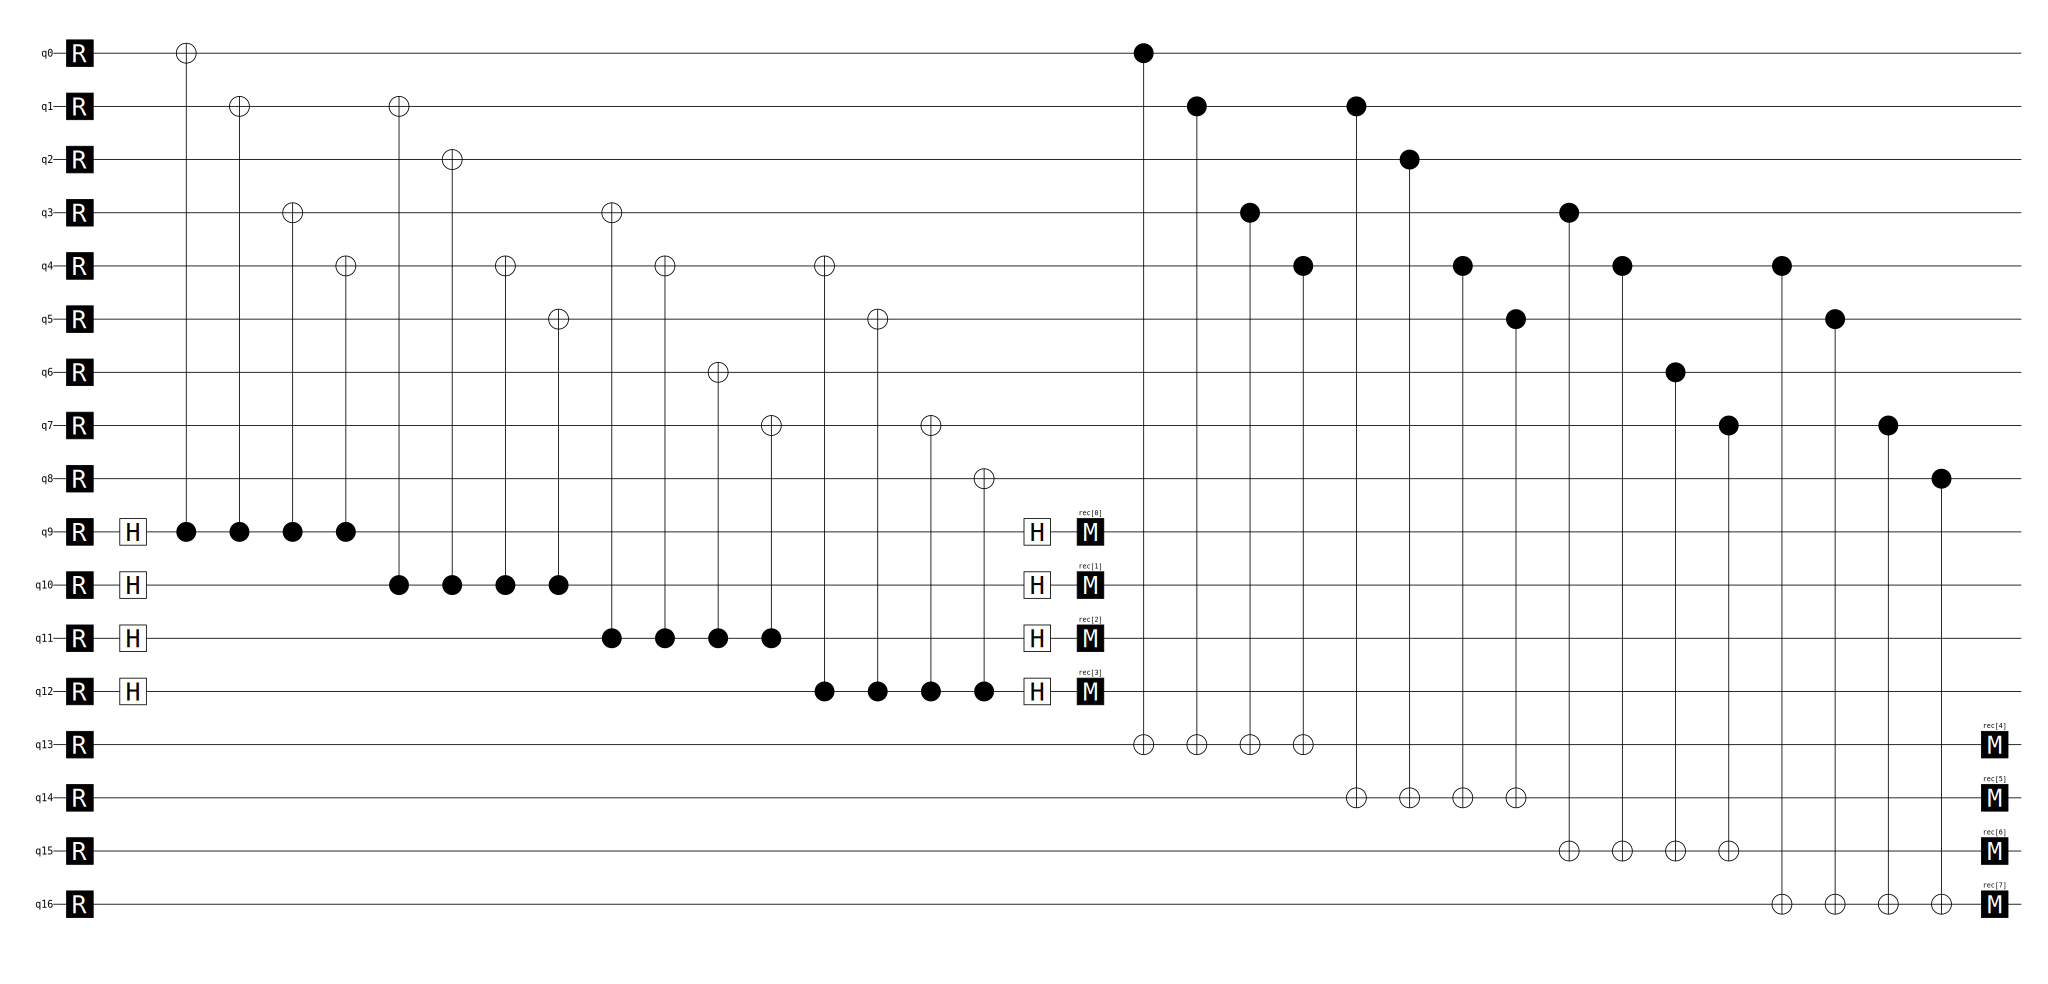

In [2]:
# print(circuit.diagram())
circuit.diagram('timeline-svg')

In [3]:
# Add simple detectors referencing measurement record
for i in range(8):
    circuit.append("DETECTOR", [stim.target_rec(-8 + i)])


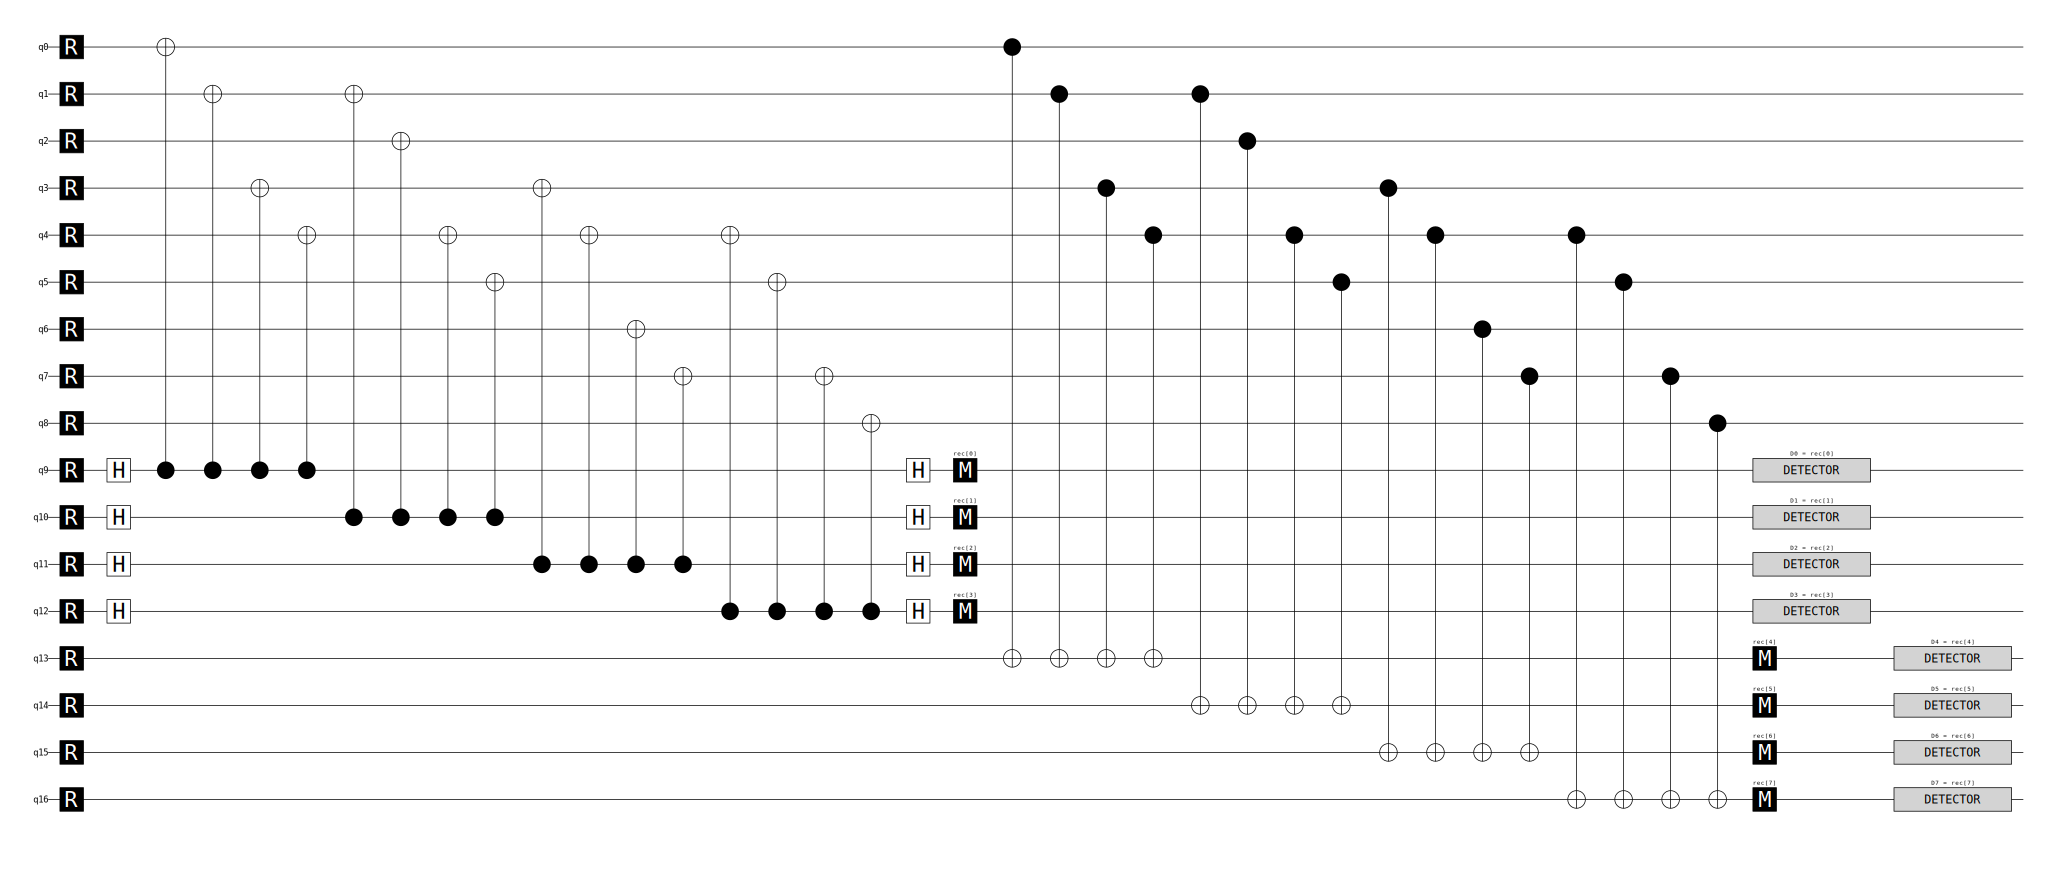

In [4]:
circuit.diagram('timeline-svg')


In [5]:
circuit.insert(0, "DEPOLARIZE1(0.001)", data)
circuit.insert(0, "DEPOLARIZE2(0.001)", circuit.findall_operations("CX"))

TypeError: insert(): incompatible function arguments. The following argument types are supported:
    1. (self: stim._stim_polyfill.Circuit, index: int, operation: object) -> None

Invoked with: stim.Circuit('''
    R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
    H 9 10 11 12
    CX 9 0 9 1 9 3 9 4 10 1 10 2 10 4 10 5 11 3 11 4 11 6 11 7 12 4 12 5 12 7 12 8
    H 9 10 11 12
    M 9 10 11 12
    CX 0 13 1 13 3 13 4 13 1 14 2 14 4 14 5 14 3 15 4 15 6 15 7 15 4 16 5 16 7 16 8 16
    M 13 14 15 16
    DETECTOR rec[-8]
    DETECTOR rec[-7]
    DETECTOR rec[-6]
    DETECTOR rec[-5]
    DETECTOR rec[-4]
    DETECTOR rec[-3]
    DETECTOR rec[-2]
    DETECTOR rec[-1]
'''), 0, 'DEPOLARIZE1(0.001)', [0, 1, 2, 3, 4, 5, 6, 7, 8]

In [ ]:
dem = circuit.detector_error_model()
print(dem)